# **1. Perkenalan Dataset**


In [ ]:
# Loan Approval Prediction Dataset

Dataset yang digunakan adalah Loan Approval Prediction Dataset yang diperoleh dari Kaggle (https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset?resource=download)

Jumlah data: 4.269 baris
Jumlah fitur: 13 kolom

Target:
- loan_status
  - Approved
  - Rejected

Tujuan:
Membangun model machine learning untuk memprediksi apakah pengajuan pinjaman akan disetujui atau ditolak berdasarkan informasi pemohon.

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier



# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
df = pd.read_csv(
    "loan_approval_dataset.csv"
)

df.head()

df.info()
df.describe()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
(4269, 13)


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


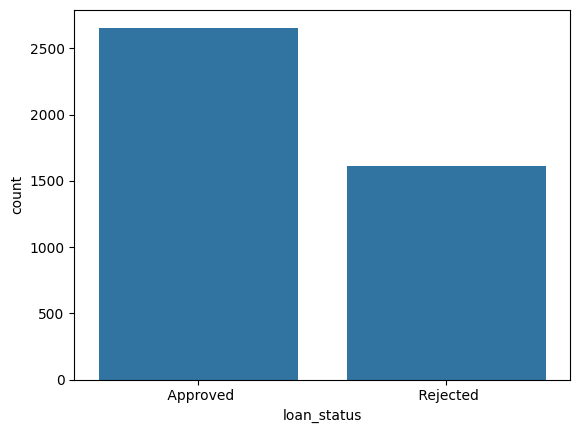

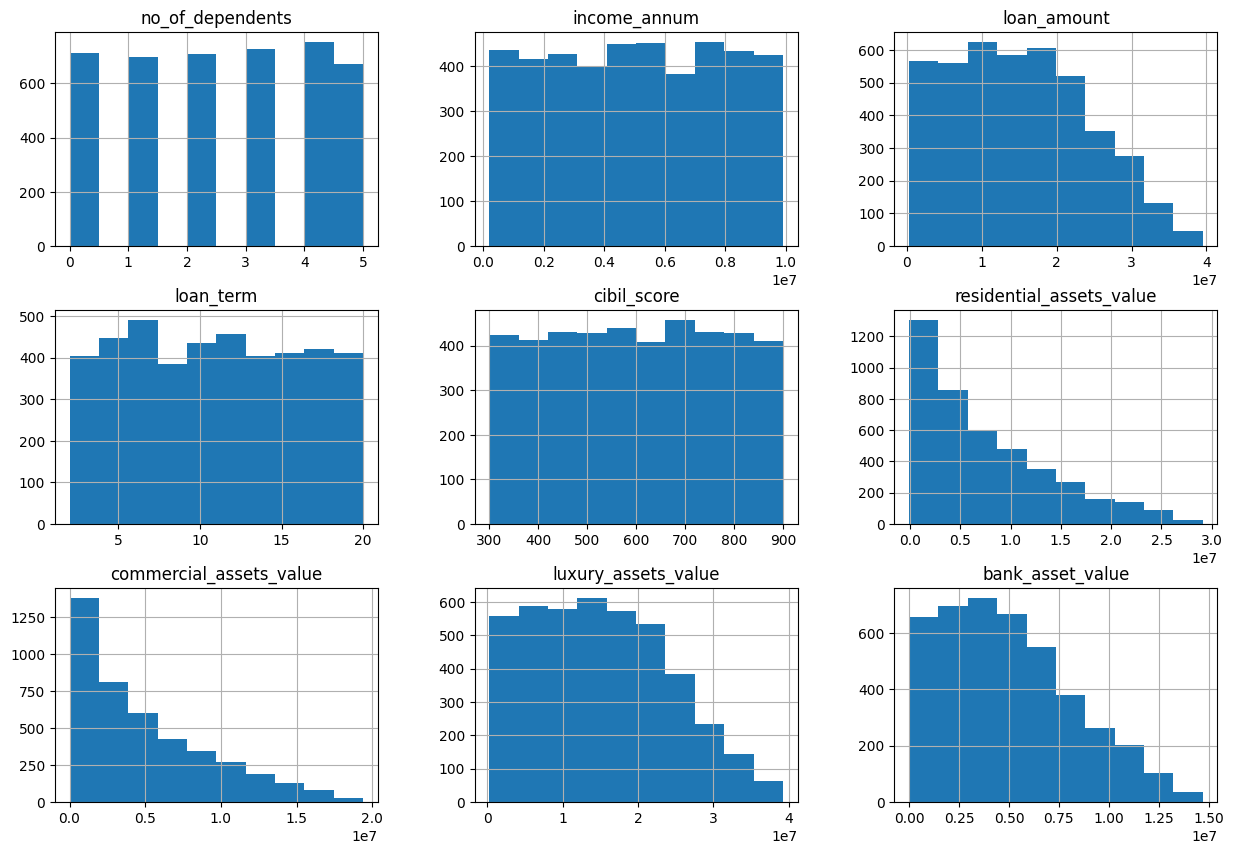

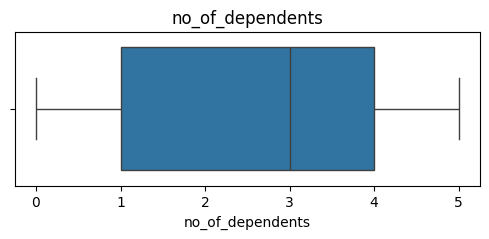

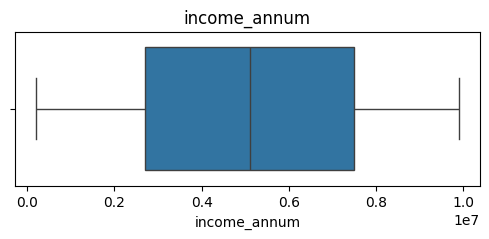

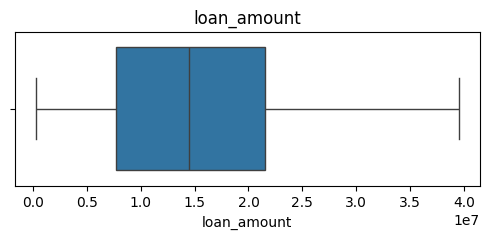

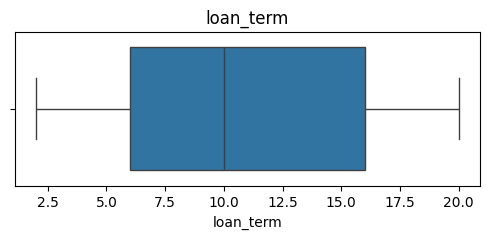

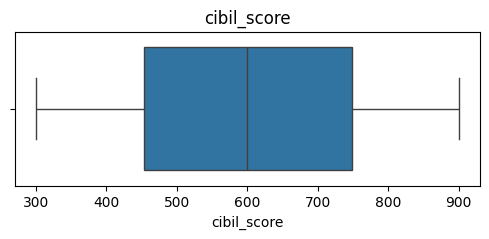

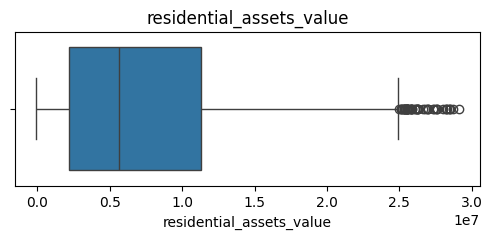

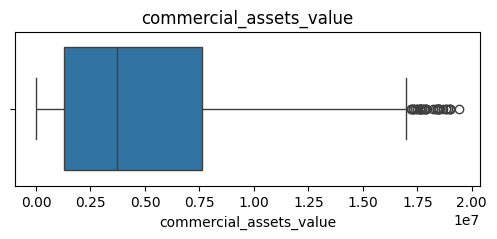

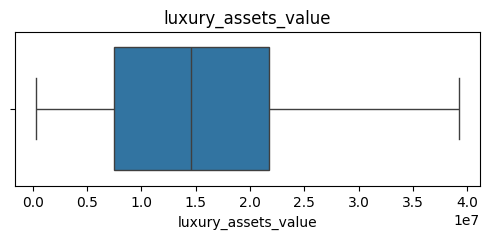

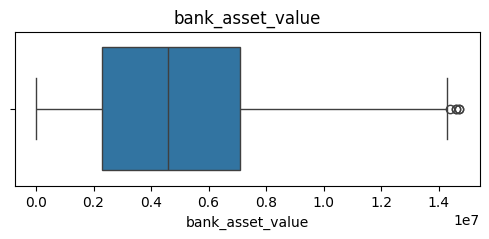

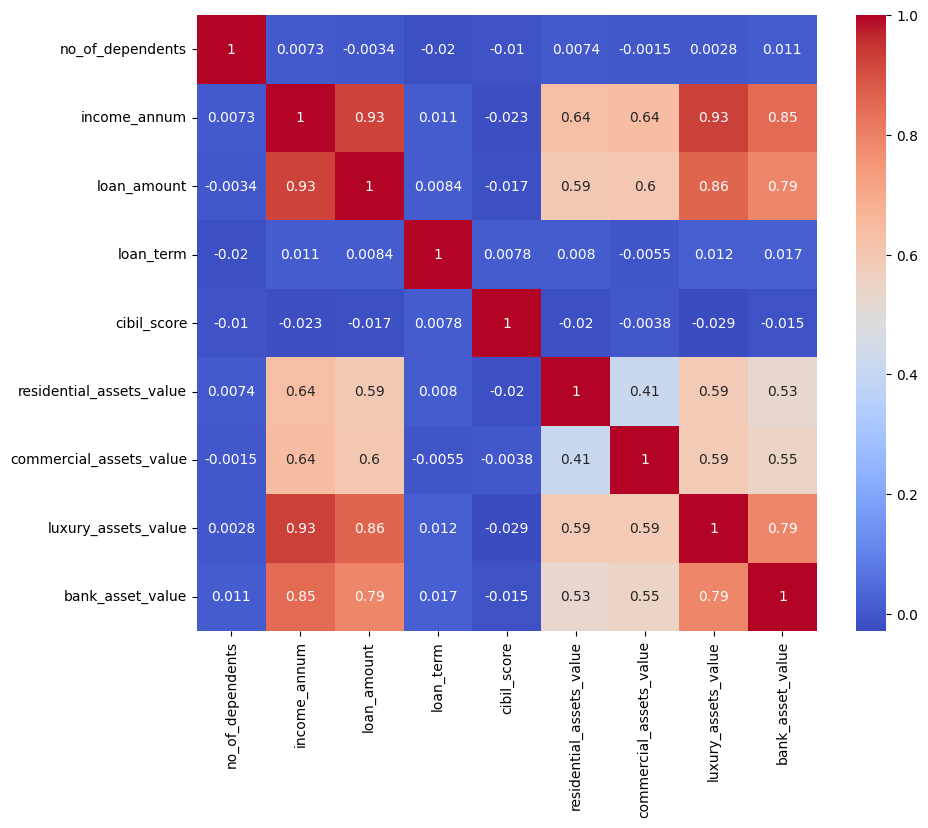

In [ ]:
# ==========================================
# CLEAN COLUMN NAMES
# ==========================================

df.columns = df.columns.str.strip()

# ==========================================
# CHECK COLUMNS
# ==========================================

print(df.columns.tolist())

df.isnull().sum()
df["loan_status"].value_counts()
sns.countplot(
    data=df,
    x="loan_status"
)

plt.show()
df.describe()
num_cols = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

df[num_cols].hist(
    figsize=(15,10)
)

plt.show()
for col in num_cols:

    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()
    corr = df[num_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
df.drop(
    columns=["loan_id"],
    inplace=True
)
df["loan_status"] = (
    df["loan_status"]
    .str.strip()
)

df["loan_status"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})
df["education"] = (
    df["education"]
    .str.strip()
)

df["self_employed"] = (
    df["self_employed"]
    .str.strip()
)

df = pd.get_dummies(
    df,
    columns=[
        "education",
        "self_employed"
    ],
    drop_first=True
)
X = df.drop(
    "loan_status",
    axis=1
)

y = df["loan_status"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)
# ==========================================
# FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(3415, 11)
(854, 11)


LOGISTIC REGRESSION
Accuracy : 0.9133
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       323
           1       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854

RANDOM FOREST
Accuracy : 0.9813
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

XGBOOST
Accuracy : 0.9801
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.9

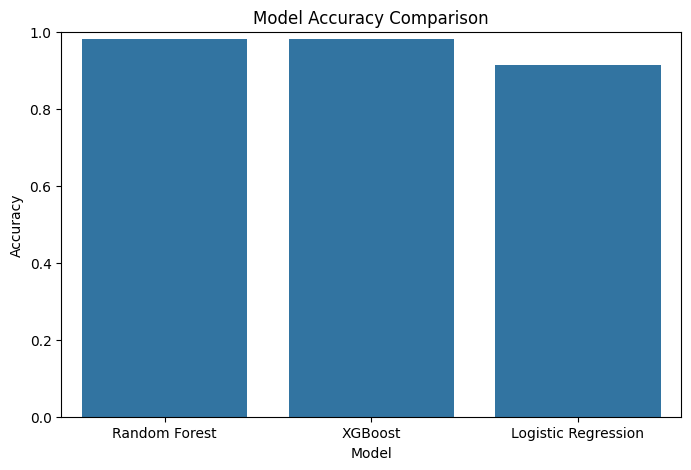


Best Model:
Model       Random Forest
Accuracy         0.981265
Name: 1, dtype: object


In [ ]:
# ==========================================
# MODELING & MODEL COMPARISON
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from xgboost import XGBClassifier

# ==========================================
# LOGISTIC REGRESSION
# ==========================================

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(
    X_test_scaled
)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)

print(
    f"Accuracy : {lr_acc:.4f}"
)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

# ==========================================
# RANDOM FOREST
# ==========================================

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("="*50)
print("RANDOM FOREST")
print("="*50)

print(
    f"Accuracy : {rf_acc:.4f}"
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

# ==========================================
# XGBOOST
# ==========================================

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print("="*50)
print("XGBOOST")
print("="*50)

print(
    f"Accuracy : {xgb_acc:.4f}"
)

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

# ==========================================
# MODEL COMPARISON
# ==========================================

result = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_acc,
        rf_acc,
        xgb_acc
    ]
})

result = result.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*50)
print("MODEL COMPARISON")
print("="*50)

print(result)

# ==========================================
# VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=result,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylim(0,1)

plt.show()

# ==========================================
# BEST MODEL
# ==========================================

best_model = result.iloc[0]

print("\nBest Model:")
print(best_model)

In [ ]:
import joblib

joblib.dump(
    rf,
    "random_forest_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model saved")

Model saved
